## Plotting Data

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss
from tqdm.notebook import trange, tqdm
import matplotlib.ticker as mticker
from tqdm import trange

Read Traces from bin file

In [8]:
### Parameters

N_TRACES = 100

### Reading

folder = '../'
fixed_folder  = folder + '/fixed/'
random_folder = folder + '/random/'

size_array = np.fromfile(fixed_folder + 'trace_0.bin', dtype=np.int64)
size = np.size(size_array)

fixed_data  = np.zeros([size,N_TRACES], dtype=np.int64)
random_data = np.zeros([size,N_TRACES], dtype=np.int64)

for i in trange(0, N_TRACES):
    fixed_data[:, i] = np.fromfile(fixed_folder + 'trace_' + str(i) +'.bin', dtype=np.int64)
    random_data[:, i] = np.fromfile(random_folder + 'trace_' + str(i) +'.bin', dtype=np.int64)


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:00<00:00, 5074.04it/s]


Plotting traces

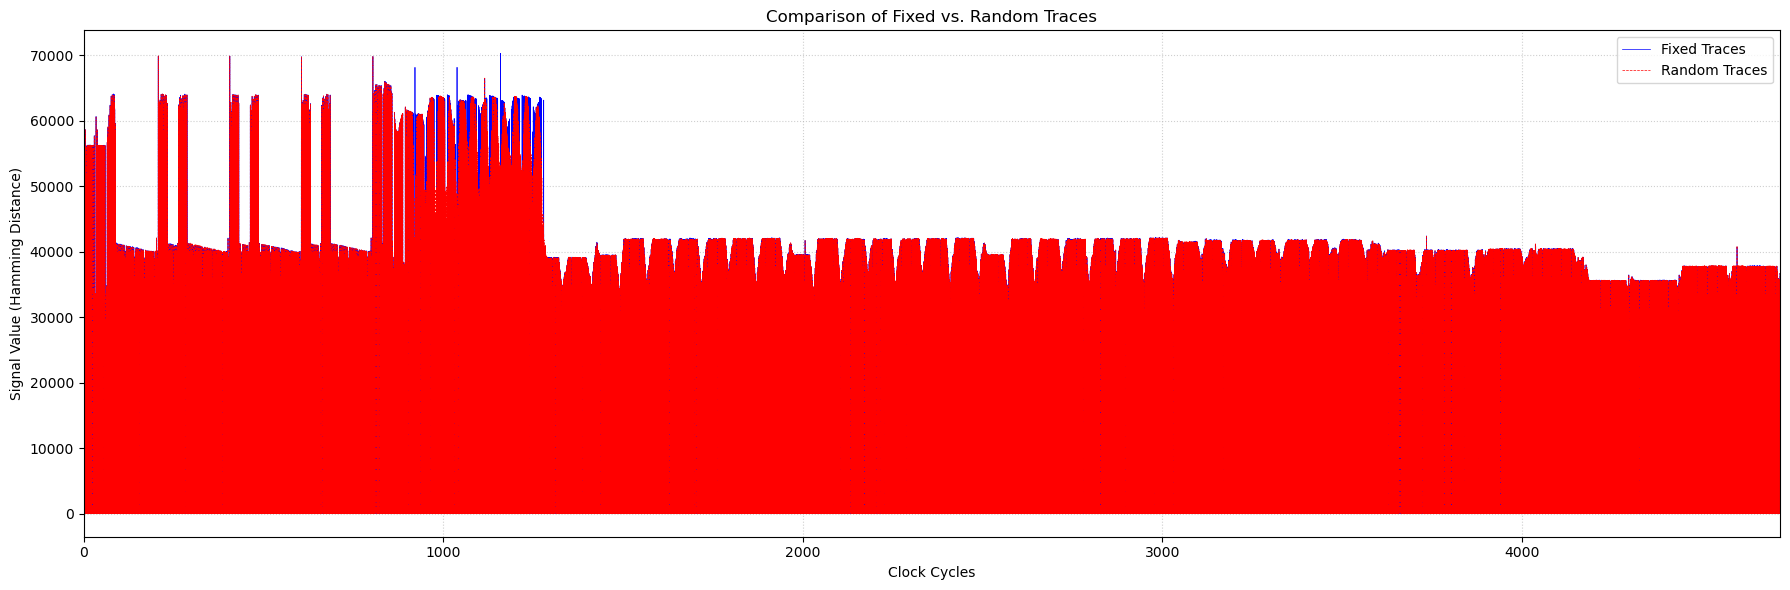

In [9]:
### Plotting
x_axis_values = np.arange(size) / 2 # Create an X-axis representing sample number

fig, ax = plt.subplots(figsize=(18, 6))

mean_fixed_data  = np.mean(fixed_data, axis=1)
mean_random_data = np.mean(random_data, axis=1)

ax.plot(x_axis_values, mean_fixed_data, label=f'Fixed Traces', color='blue', linewidth=0.5) 
ax.plot(x_axis_values, mean_random_data, label=f'Random Traces', color='red', linestyle='--', linewidth=0.5)

ax.set_xlim(0, size/2)

ax.set_xlabel('Clock Cycles')
ax.set_ylabel('Signal Value (Hamming Distance)')
ax.set_title(f'Comparison of Fixed vs. Random Traces')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## Univariate T-Test

First Order Univariate T-test

/usr/lib/python3/dist-packages/scipy/stats/_axis_nan_policy.py:551: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


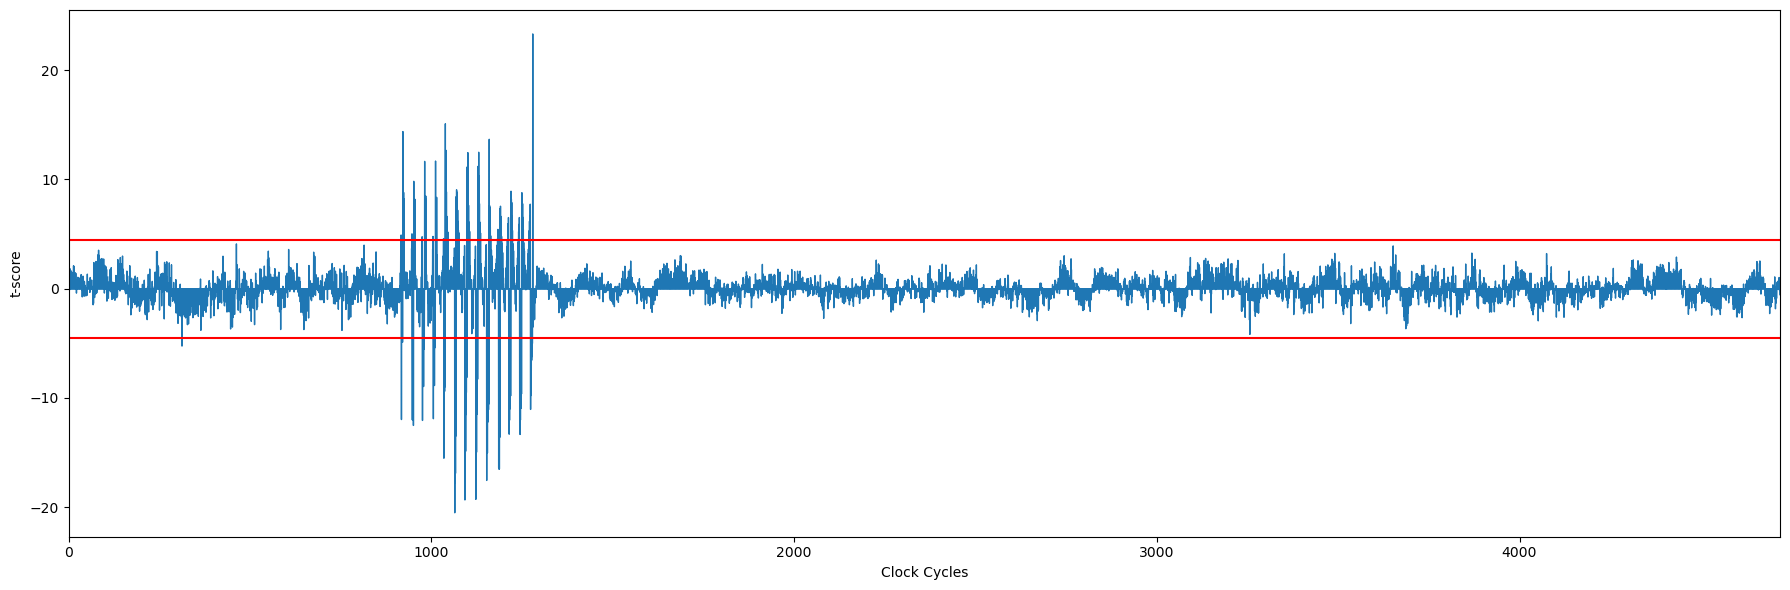

In [10]:
# Calculate t-test
t_test_1 = ss.ttest_ind(np.transpose(fixed_data), np.transpose(random_data), axis=0, equal_var=False)
t_score = np.nan_to_num(t_test_1[0]) # Remove any possible NaN value

#print t_test
x_axis_values = np.arange(size) / 2

CRITICAL_VALUE = 4.5

fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(x_axis_values, t_score, linewidth=1) #, color='blue', linewidth=1)
plt.axhline(y = CRITICAL_VALUE, color = 'r', linestyle='-')
plt.axhline(y = -CRITICAL_VALUE, color = 'r', linestyle='-')

ax.set_xlim(0,size/2)

ax.set_xlabel('Clock Cycles')
ax.set_ylabel('t-score')

plt.tight_layout()
plt.show()

Second Order Univariate T-test


 Concatenating data ... 


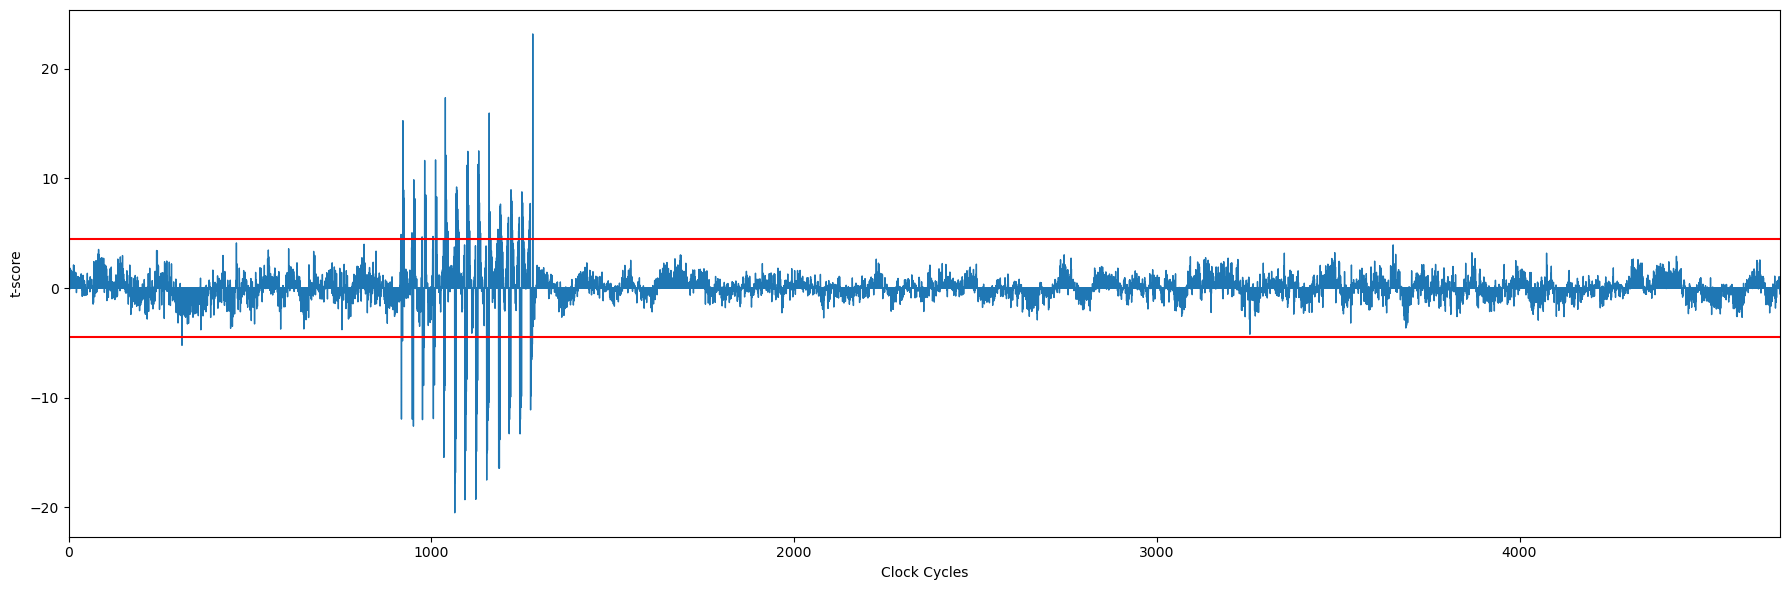

In [11]:
concat = np.zeros(shape=(2*N_TRACES, len(fixed_data)))

print("\n Concatenating data ... ")
for i in range(0, N_TRACES):
    concat[2*i + 0, :] = fixed_data[:, i]
    concat[2*i + 1, :] = random_data[:, i]

mean = np.mean(concat)
data_fixed_2 = np.power(fixed_data - mean, 2)
data_random_2 = np.power(random_data - mean, 2)

t_test_2 = ss.ttest_ind(np.transpose(data_fixed_2), np.transpose(data_random_2), axis=0, equal_var=False)
t_score_2 = np.nan_to_num(t_test_2[0]) # Remove any possible NaN value

#print t_test
x_axis_values = np.arange(size) / 2

CRITICAL_VALUE = 4.5

fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(x_axis_values, t_score_2, linewidth=1) #, color='blue', linewidth=1)
plt.axhline(y = CRITICAL_VALUE, color = 'r', linestyle='-')
plt.axhline(y = -CRITICAL_VALUE, color = 'r', linestyle='-')

ax.set_xlim(0,size/2)

ax.set_xlabel('Clock Cycles')
ax.set_ylabel('t-score')

plt.tight_layout()
plt.show()

Third Order Univariate T-test


 Concatenating data ... 


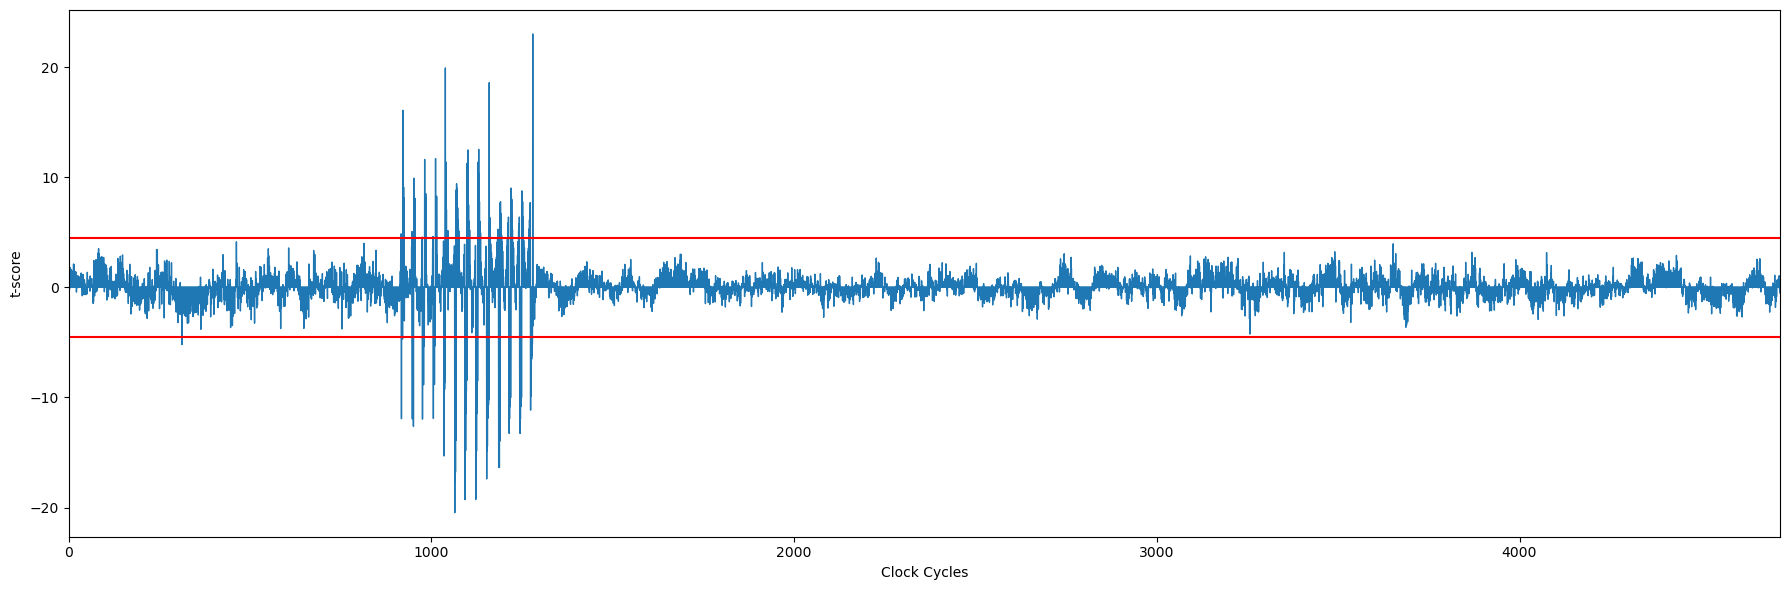

In [12]:
concat = np.zeros(shape=(2*N_TRACES, len(fixed_data)))

print("\n Concatenating data ... ")
for i in range(0, N_TRACES):
    concat[2*i + 0, :] = fixed_data[:, i]
    concat[2*i + 1, :] = random_data[:, i]

mean = np.mean(concat)
std = np.std(concat)
data_fixed_3 = np.power(fixed_data - mean, 3) / std
data_random_3 = np.power(random_data - mean, 3) / std

t_test_3 = ss.ttest_ind(np.transpose(data_fixed_3), np.transpose(data_random_3), axis=0, equal_var=False)
t_score_3 = np.nan_to_num(t_test_3[0]) # Remove any possible NaN value

#print t_test
x_axis_values = np.arange(size) / 2

CRITICAL_VALUE = 4.5

fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(x_axis_values, t_score_3, linewidth=1) #, color='blue', linewidth=1)
plt.axhline(y = CRITICAL_VALUE, color = 'r', linestyle='-')
plt.axhline(y = -CRITICAL_VALUE, color = 'r', linestyle='-')

ax.set_xlim(0,size/2)

ax.set_xlabel('Clock Cycles')
ax.set_ylabel('t-score')

plt.tight_layout()
plt.show()

Fourth Order Univariate T-test


 Concatenating data ... 


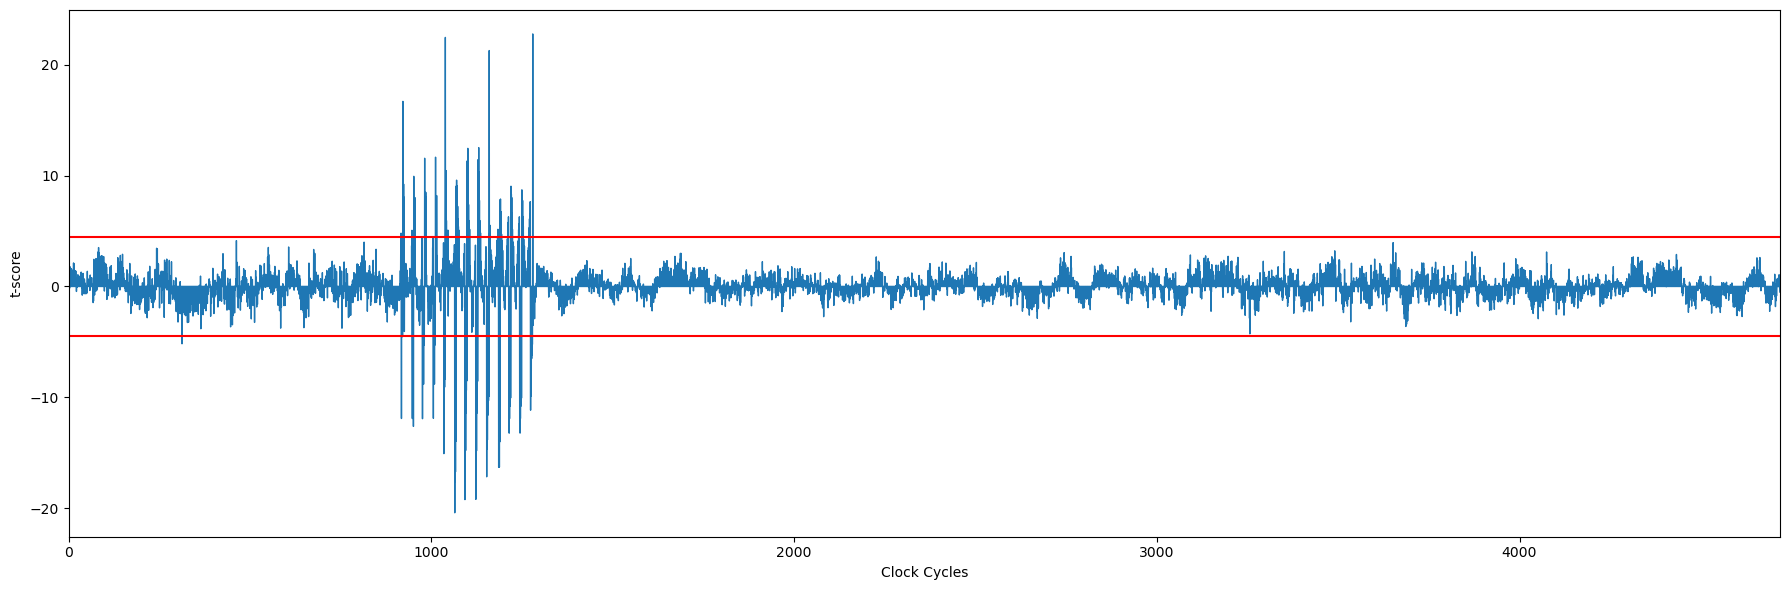

In [13]:
concat = np.zeros(shape=(2*N_TRACES, len(fixed_data)))

print("\n Concatenating data ... ")
for i in range(0, N_TRACES):
    concat[2*i + 0, :] = fixed_data[:, i]
    concat[2*i + 1, :] = random_data[:, i]

mean = np.mean(concat)
std = np.std(concat)
data_fixed_4 = np.power(fixed_data - mean, 4) / std
data_random_4 = np.power(random_data - mean, 4) / std

t_test_4 = ss.ttest_ind(np.transpose(data_fixed_4), np.transpose(data_random_4), axis=0, equal_var=False)
t_score_4 = np.nan_to_num(t_test_4[0]) # Remove any possible NaN value

#print t_test
x_axis_values = np.arange(size) / 2

CRITICAL_VALUE = 4.5

fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(x_axis_values, t_score_4, linewidth=1) #, color='blue', linewidth=1)
plt.axhline(y = CRITICAL_VALUE, color = 'r', linestyle='-')
plt.axhline(y = -CRITICAL_VALUE, color = 'r', linestyle='-')

ax.set_xlim(0,size/2)

ax.set_xlabel('Clock Cycles')
ax.set_ylabel('t-score')

plt.tight_layout()
plt.show()

## Multivariate T-Test

100%|██████████| 100/100 [00:02<00:00, 38.99it/s]

[-1.01420337 -1.02584311 -1.0186451  ...         nan         nan
         nan]


(-10.0, 10.0)

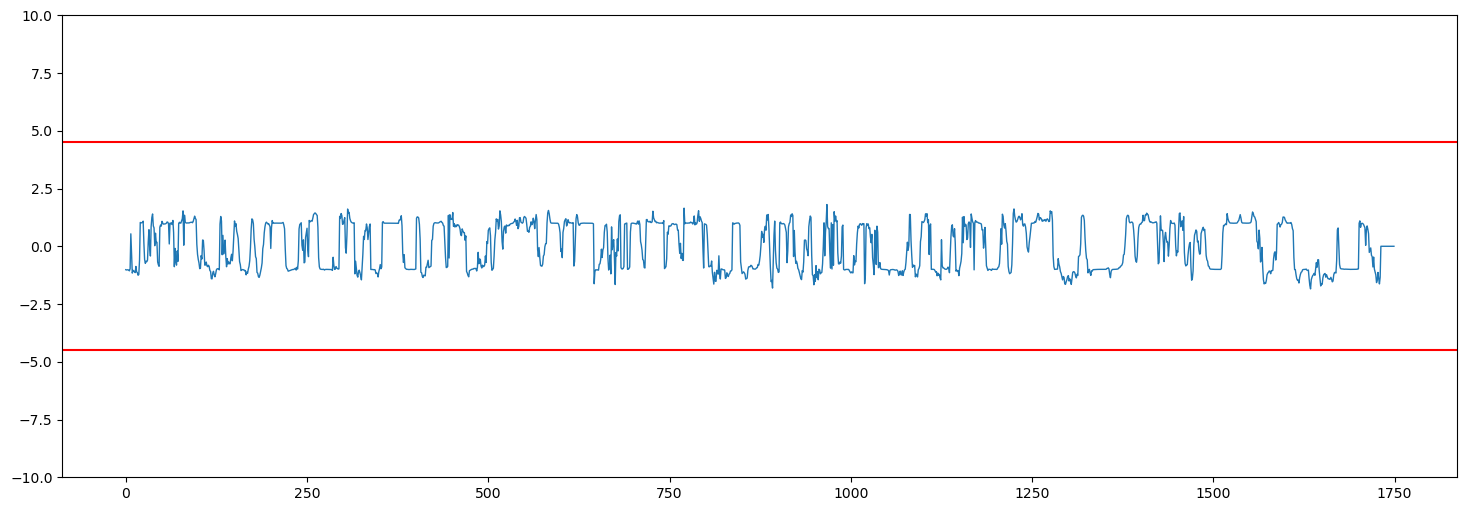

In [ ]:
d = 4 # Windows size (Order - 1)
stats = []
n_ini = 0
n_end = np.arange(size)
n_ini = np.int32(n_ini / 2)
n_end = np.int32(n_end / 2)
n_samples = np.int32((n_end - n_ini))
# n_samples = size
 
XF = fixed_data[1::2, :] # Removing the nedegde cycle 
XR = random_data[1::2, :]

mean_fixed_data  = np.mean(XF, axis=1)
mean_random_data = np.mean(XR, axis=1)

std_fixed_data = np.std(XF, axis=1, dtype=np.float64)
std_random_data = np.std(XR, axis=1, dtype=np.float64)

MF = np.zeros([n_samples,N_TRACES], dtype=np.float64)
MR = np.zeros([n_samples,N_TRACES], dtype=np.float64)

for n in trange(N_TRACES):
        for j in range(n_ini, n_end - d + 1):
                mult_FL = 1.0
                mult_RL = 1.0

                for d_val in range(1, d):
                        # Extract window
                        mult_FL = mult_FL * ((XF[j+d_val , n] - mean_fixed_data[j+d_val]) / std_fixed_data[j+d_val])
                        mult_RL = mult_RL * ((XR[j+d_val , n] - mean_random_data[j+d_val]) / std_random_data[j+d_val])

                MF[j-n_ini, n] = MF[j-n_ini, n] + (mult_FL / N_TRACES)
                MR[j-n_ini, n] = MR[j-n_ini, n] + (mult_RL / N_TRACES)

# Calculate t-test
t_test_multi_1 = ss.ttest_ind(np.transpose(MF), np.transpose(MR), axis=0, equal_var=False)
print(t_test_multi_1[0])
# Remove any possible NaN value
t_score = np.nan_to_num(t_test_multi_1[0])

fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(t_score, linewidth=1) #, color='blue', linewidth=1)
plt.axhline(y = 4.5, color = 'r', linestyle='-')
plt.axhline(y = -4.5, color = 'r', linestyle='-')

ax.set_ylim(-10, 10)
